# Chapter 11 — Electrochemistry of Strongly Adsorbed Molecules

*Python-native adaptation of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 11
("Electrochemistry of Strongly Adsorbed Molecules"). The original
`chapter11.nb` is the reference for the physics and algorithms; the code here
is an idiomatic numpy / scipy / matplotlib re-implementation, and every
quantitative claim is re-derived or re-validated in-notebook.*

## What is different about an adsorbed species

In every earlier chapter the electroactive molecule lives in solution and must
**diffuse** to the electrode; the current is set by a flux and Fick's law fills
the simulation with a partial differential equation in space and time. This
chapter treats the opposite limit: the redox molecule is **strongly adsorbed**
(or covalently tethered) to the electrode surface. There is no diffusion and no
mass transport — only a fixed population of surface molecules switching between
the oxidised and reduced state under electrode kinetics.

Consider the surface-confined reduction $\mathrm{O} + n e^- \rightleftharpoons
\mathrm{R}$, where both $\mathrm{O}$ and $\mathrm{R}$ are bound. Let
$\Gamma_\mathrm{O}(t)$ and $\Gamma_\mathrm{R}(t)$ be the surface concentrations
(mol cm$^{-2}$). The faradaic current is

$$ i = n F A\,\bigl(k_f\,\Gamma_\mathrm{O} - k_b\,\Gamma_\mathrm{R}\bigr), $$

where $k_f$ and $k_b$ are the forward (reductive) and backward (oxidative)
heterogeneous rate constants (s$^{-1}$ for a surface reaction); the cathodic
reduction consumes $\mathrm{O}$ at rate $k_f\Gamma_\mathrm{O}$ and the anodic
back-reaction regenerates it at $k_b\Gamma_\mathrm{R}$. The total coverage
$\Gamma_\mathrm{T} = \Gamma_\mathrm{O} + \Gamma_\mathrm{R}$ is constant
throughout the experiment — molecules are neither created nor lost, they only
interconvert. Dividing through by $\Gamma_\mathrm{T}$ and writing the **mole
fractions** $x_\mathrm{O} = \Gamma_\mathrm{O}/\Gamma_\mathrm{T}$ and
$x_\mathrm{R} = 1 - x_\mathrm{O}$,

$$ i = n F A\,\Gamma_\mathrm{T}\,\bigl(k_f\,x_\mathrm{O} - k_b\,x_\mathrm{R}\bigr). $$

Because the whole problem reduces to one ordinary differential equation for a
single scalar $x_\mathrm{O}(t)$, the simulations in this chapter are far cheaper
than the diffusion problems — but the physics (Butler–Volmer kinetics, the
reversible/quasi-reversible/irreversible transition, Marcus theory) is just as
rich.

## Kinetics and the dimensionless potential

We adopt Butler–Volmer kinetics. With the dimensionless overpotential measured
from the formal potential $E^{\circ\prime}$,

$$ \mathcal{E} \;=\; \frac{nF}{RT}\,\bigl(E - E^{\circ\prime}\bigr), $$

the forward and backward rate constants are

$$ k_f = k_s\,e^{-\alpha \mathcal{E}}, \qquad
   k_b = k_s\,e^{(1-\alpha)\mathcal{E}}, $$

where $k_s$ is the standard rate constant (s$^{-1}$) and $\alpha$ the transfer
coefficient. The mole-fraction balance for the bound species is

$$ \frac{\mathrm{d} x_\mathrm{O}}{\mathrm{d} t}
   = -k_f\,x_\mathrm{O}\;+\;k_b\,(1 - x_\mathrm{O})
   \quad\Longleftrightarrow\quad
   \frac{\mathrm{d} x_\mathrm{O}}{\mathrm{d} t}
   = -(k_f + k_b)\,x_\mathrm{O} + k_b .$$

(SERM writes the same balance; the equilibrium mole fraction is
$x_\mathrm{O}^{\,\mathrm{eq}} = k_b/(k_f+k_b)$, which — using
$k_b/k_f = e^{\mathcal{E}}$ — is exactly the Nernst result
$1/(1+e^{-\mathcal{E}})$.)

## Section 1 — Potential-step relaxation (closed form)

When the potential is **stepped** and then held, $\mathcal{E}$ is fixed, so
$k_f$ and $k_b$ are constants. The balance
$\dot x_\mathrm{O} = -(k_f+k_b)\,x_\mathrm{O} + k_b$ is then a linear ODE with
constant coefficients. With the initial mole fraction $x_\mathrm{O}(0)=x_{Oi}$
it integrates to

$$ x_\mathrm{O}(t) = x_\mathrm{O}^{\,\mathrm{eq}}
   + \bigl(x_{Oi} - x_\mathrm{O}^{\,\mathrm{eq}}\bigr)\,
     e^{-(k_f+k_b)\,t},
   \qquad x_\mathrm{O}^{\,\mathrm{eq}} = \frac{k_b}{k_f+k_b}. $$

This is SERM's potential-step result, obtained there with `DSolve`. The current
is a single decaying exponential,

$$ i(t) = n F A\,\Gamma_\mathrm{T}\,
   \bigl(k_f\,x_\mathrm{O} - k_b\,x_\mathrm{R}\bigr)
   = n F A\,\Gamma_\mathrm{T}\,(k_f+k_b)
     \bigl(x_{Oi} - x_\mathrm{O}^{\,\mathrm{eq}}\bigr)
     e^{-(k_f+k_b)\,t}, $$

with a single time constant $\tau_c = 1/(k_f+k_b)$ — a clean exponential decay,
unlike the $t^{-1/2}$ Cottrell decay of a diffusing species. We verify the
closed form against a black-box ODE integration of the balance below.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import serm
from serm.echem import F, R, surface_wave_peak_current

T = 298.15           # K (25 C, the temperature for the 90.6/n mV criterion)
f_RT = F / (R * T)   # n F / RT per electron


def bv_rates(script_E, k_s, alpha=0.5):
    """Butler-Volmer forward/backward surface rate constants.

    Parameters
    ----------
    script_E : array_like
        Dimensionless overpotential ``nF(E - E0)/RT``.
    k_s : float
        Standard rate constant (s^-1).
    alpha : float
        Transfer coefficient.

    Returns
    -------
    k_f, k_b : ndarray
        Forward (reductive) and backward (oxidative) rate constants (s^-1).
    """
    script_E = np.asarray(script_E, dtype=float)
    k_f = k_s * np.exp(-alpha * script_E)
    k_b = k_s * np.exp((1.0 - alpha) * script_E)
    return k_f, k_b


In [2]:
def step_xO_closed(t, k_f, k_b, x_Oi):
    "Closed-form mole fraction x_O(t) after a potential step (constant k_f,k_b)."
    x_eq = k_b / (k_f + k_b)
    return x_eq + (x_Oi - x_eq) * np.exp(-(k_f + k_b) * t)


# Step from a strongly reducing hold (x_O ~ 0) to E0 + a reducing overpotential.
k_s = 1.0                      # s^-1
script_E_step = -2.0           # dimensionless overpotential held after the step
k_f, k_b = bv_rates(script_E_step, k_s)
k_f, k_b = float(k_f), float(k_b)
x_Oi = 1.0                     # start fully oxidised, relax toward equilibrium
t = np.linspace(0.0, 5.0, 400)

x_closed = step_xO_closed(t, k_f, k_b, x_Oi)

# Independent black-box check: integrate the balance ODE numerically.
# dx_O/dt = -k_f x_O + k_b (1 - x_O) = -(k_f + k_b) x_O + k_b
sol = solve_ivp(lambda _t, x: -(k_f + k_b) * x[0] + k_b,
                (t[0], t[-1]), [x_Oi], t_eval=t, rtol=1e-10, atol=1e-12)
x_num = sol.y[0]

print("max |closed - numeric| over the step transient:",
      np.max(np.abs(x_closed - x_num)))
print("equilibrium x_O =", k_b / (k_f + k_b),
      "  Nernst 1/(1+exp(-E)) =", 1.0 / (1.0 + np.exp(-script_E_step)))


max |closed - numeric| over the step transient: 8.144096508289067e-12
equilibrium x_O = 0.11920292202211756   Nernst 1/(1+exp(-E)) = 0.11920292202211755


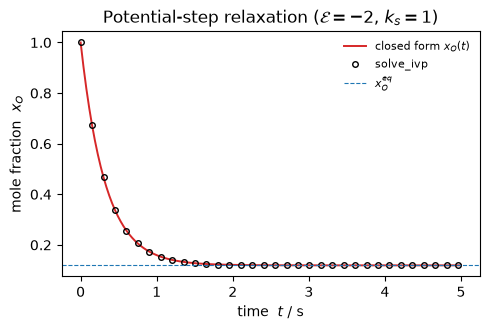

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(t, x_closed, color="C3", lw=1.4, label=r"closed form $x_O(t)$")
ax.plot(t[::12], x_num[::12], "o", ms=4, color="k", mfc="none",
        label="solve_ivp")
ax.axhline(float(k_b / (k_f + k_b)), color="C0", ls="--", lw=0.8,
           label=r"$x_O^{eq}$")
ax.set_xlabel("time  $t$ / s")
ax.set_ylabel(r"mole fraction  $x_O$")
ax.set_title(r"Potential-step relaxation ($\mathcal{E}=-2$, $k_s=1$)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Section 2 — Constant-current (chronopotentiometric) method

Instead of controlling the potential we can control the **current**. Hold the
faradaic current at a fixed value $i$ and record how the potential evolves; the
natural observable is $\mathrm{d}t/\mathrm{d}E$ plotted against $E$. For a
surface-confined couple the current is the rate at which $\mathrm{R}$ is formed,

$$ i = n F A\,\Gamma_\mathrm{T}\,\frac{\mathrm{d}x_\mathrm{R}}{\mathrm{d}t}, $$

so a **constant** current forces $\mathrm{d}x_\mathrm{R}/\mathrm{d}t$ constant —
the reduced fraction grows *linearly in time*, and the whole monolayer is
converted in a fixed transition time. Rearranging,

$$ \frac{\mathrm{d}t}{\mathrm{d}E}
   = \frac{n F A\,\Gamma_\mathrm{T}}{i}\,
     \frac{\mathrm{d}x_\mathrm{R}}{\mathrm{d}E}. $$

It is convenient to make the current dimensionless. With Butler–Volmer kinetics
($\xi = e^{\mathcal{E}} = e^{(nF/RT)(E-E^{\circ\prime})}$) the steady balance

$$ i = nFA\Gamma_\mathrm{T} k_s\bigl(\xi^{1-\alpha} x_\mathrm{R}
       - \xi^{-\alpha}(1-x_\mathrm{R})\bigr) $$

can be solved for $x_\mathrm{R}(\xi)$ — SERM does this with `Solve` — and the
**dimensionless current** is

$$ \psi \;\equiv\; \frac{i}{n F A\,\Gamma_\mathrm{T} k_s}
   \;=\; -\,\xi\,\frac{\mathrm{d}x_\mathrm{R}}{\mathrm{d}\xi}
   \;=\; -\,\frac{\mathrm{d}x_\mathrm{R}}{\mathrm{d}\mathcal{E}}, $$

using the chain rule $\mathrm{d}/\mathrm{d}\mathcal{E} = \xi\,\mathrm{d}/\mathrm{d}\xi$.

**Reversible limit.** For large $k_s$ the surface stays Nernstian,
$x_\mathrm{R} = 1/(1+\xi)$, and

$$ \psi_\mathrm{rev}(\xi)
   = -\,\xi\,\frac{\mathrm{d}}{\mathrm{d}\xi}\!\frac{1}{1+\xi}
   = \frac{\xi}{(1+\xi)^2}
   = \frac{1}{4}\,\operatorname{sech}^2\!\frac{\mathcal{E}}{2}. $$

This is the **same symmetric peak** as the reversible LSV wave: it reaches its
maximum value $\psi_{\max} = \tfrac14$ when $\xi = 1$ (i.e. $E = E^{\circ\prime}$)
and has a peak width at half height of $90.6/n$ mV at 25 °C. Since
$\mathrm{d}t/\mathrm{d}E = (nFA\Gamma_\mathrm{T}/i)\,\mathrm{d}x_\mathrm{R}/\mathrm{d}E
= -(nFA\Gamma_\mathrm{T} k_s/i)\,\psi$, the measured $|\mathrm{d}t/\mathrm{d}E|$
is directly proportional to $\psi$, so a chronopotentiogram of an adsorbed
reversible couple shows a **symmetric peak of height $0.25$ at the formal
potential** — the chronopotentiometric twin of the LSV surface wave.

We implement two complementary views below: the closed-form reversible
$\psi_\mathrm{rev}(\mathcal{E})$, and the **galvanostatic chronopotentiogram**
obtained by inverting the Butler–Volmer steady relation at a *fixed applied
current* $\psi$, which broadens away from the reversible peak as $\psi$ grows
and recovers it exactly as $\psi\to 0$.

In [4]:
def cc_psi_reversible(script_E):
    """Reversible dimensionless constant-current response psi(E).

    psi = xi/(1+xi)^2 = (1/4) sech^2(E/2), the chronopotentiometric surface
    peak. ``script_E`` is the dimensionless overpotential nF(E-E0)/RT.
    """
    script_E = np.asarray(script_E, dtype=float)
    xi = np.exp(script_E)
    return xi / (1.0 + xi) ** 2


def cc_xR_of_xi(xi, psi, alpha=0.5):
    """Surface reduced fraction x_R(xi) sustaining dimensionless current psi.

    From the Butler-Volmer steady relation
    psi = xi^{1-alpha} x_R - xi^{-alpha}(1 - x_R), solved for x_R.
    """
    xi = np.asarray(xi, dtype=float)
    return (xi ** (-alpha) + psi) / (xi ** (1.0 - alpha) + xi ** (-alpha))


def cc_chronopotentiogram(psi, alpha=0.5, n_pts=4001, eps=1e-9):
    """Galvanostatic chronopotentiogram: E(x_R) and dt/dE vs E at fixed psi.

    At *constant current* the dimensionless current ``psi`` is the controlled
    quantity and the reduced fraction ``x_R`` runs linearly in time from 0 to 1
    (constant dx_R/dt). At each instant the Butler-Volmer steady relation

        psi = xi^{1-alpha} x_R - xi^{-alpha} (1 - x_R)

    must hold; inverting it for ``xi`` at the running ``x_R`` gives the
    potential trajectory. The relation is monotone increasing in
    ``E = ln xi`` at fixed ``x_R``, so we invert by a vectorized bisection.
    Returns ``(E, x_R, dtdE)`` where ``dtdE`` is proportional to the measured
    ``dt/dE`` (= dx_R/dE up to the constant nFA Gamma_T / i).

    As ``psi -> 0`` the relation reduces to the Nernstian ``x_R = 1/(1+xi)``
    and ``dt/dE`` becomes the reversible ``(1/4) sech^2(E/2)`` peak.
    """
    x_R = np.linspace(eps, 1.0 - eps, n_pts)

    def g(E):
        xi = np.exp(E)
        return xi ** (1.0 - alpha) * x_R - xi ** (-alpha) * (1.0 - x_R) - psi

    lo = np.full_like(x_R, -80.0)
    hi = np.full_like(x_R, 80.0)
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        pos = g(mid) > 0.0
        hi = np.where(pos, mid, hi)
        lo = np.where(pos, lo, mid)
    E = 0.5 * (lo + hi)

    dtdE = np.gradient(x_R, E)   # proportional to dt/dE (constant current)
    return E, x_R, dtdE


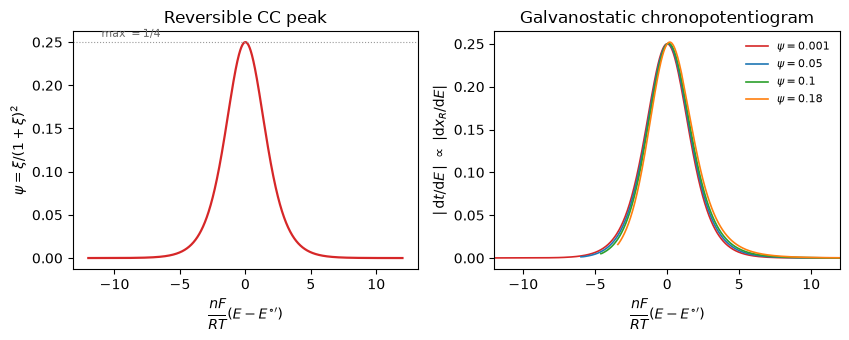

In [5]:
# Reversible chronopotentiometric peak (analytic) and galvanostatic
# chronopotentiograms inverted from the Butler-Volmer steady relation.
E_grid = np.linspace(-12, 12, 2001)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.5))

# Left: the reversible dimensionless current peak, xi/(1+xi)^2.
ax1.plot(E_grid, cc_psi_reversible(E_grid), color="C3", lw=1.6)
ax1.axhline(0.25, color="0.6", ls=":", lw=0.8)
ax1.text(-11, 0.255, r"max $=1/4$", fontsize=8, color="0.4")
ax1.set_xlabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime})$")
ax1.set_ylabel(r"$\psi=\xi/(1+\xi)^2$")
ax1.set_title("Reversible CC peak")

# Right: galvanostatic dt/dE (proportional) for several applied currents psi.
for psi_app, c in [(0.001, "C3"), (0.05, "C0"), (0.10, "C2"), (0.18, "C1")]:
    E, x_R, dtdE = cc_chronopotentiogram(psi_app)
    ax2.plot(E, np.abs(dtdE), color=c, lw=1.2, label=fr"$\psi={psi_app:g}$")
ax2.set_xlim(-12, 12)
ax2.set_xlabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime})$")
ax2.set_ylabel(r"$|\,\mathrm{d}t/\mathrm{d}E\,|\ \propto\ |\mathrm{d}x_R/\mathrm{d}E|$")
ax2.set_title("Galvanostatic chronopotentiogram")
ax2.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


### Galvanostatic (constant-current) chronopotentiogram

In a real constant-current experiment the **current is the controlled
quantity**: the dimensionless current $\psi$ is held fixed and the potential is
the response. Because $i = nFA\Gamma_\mathrm{T}\,\mathrm{d}x_\mathrm{R}/\mathrm{d}t$
is constant, $x_\mathrm{R}$ advances *linearly in time* from $0$ to $1$; the
whole monolayer is reduced in a fixed transition time. At every instant the
Butler–Volmer steady relation

$$ \psi = \xi^{1-\alpha}\,x_\mathrm{R} - \xi^{-\alpha}\,(1 - x_\mathrm{R}) $$

ties the running $x_\mathrm{R}$ to the potential $\xi=e^{\mathcal{E}}$. The
left-hand side is monotone increasing in $\mathcal{E}$ at fixed $x_\mathrm{R}$,
so the relation inverts cleanly for $\mathcal{E}(x_\mathrm{R})$ — the
chronopotentiogram — and the measured $|\mathrm{d}t/\mathrm{d}E| \propto
|\mathrm{d}x_\mathrm{R}/\mathrm{d}E|$ follows by differentiation
(`cc_chronopotentiogram` above does exactly this by vectorized bisection).

As $\psi\to 0$ the relation collapses to $\xi = (1-x_\mathrm{R})/x_\mathrm{R}$,
i.e. the Nernstian $x_\mathrm{R}=1/(1+\xi)$, and $|\mathrm{d}t/\mathrm{d}E|$
recovers the reversible $\tfrac14\operatorname{sech}^2(\mathcal{E}/2)$ peak. For
a finite applied current the curve **broadens and shifts** as the kinetic
overpotential needed to sustain $\psi$ grows — the constant-current analogue of
the quasi-reversible LSV transition. We verify the $\psi\to 0$ reduction, the
symmetric reversible peak, and coverage conservation next.

In [6]:
# --- Validation of the constant-current method -------------------------
# Tier 1 (closed-form analytic) + Tier 2 (reduction to validated reversible
# limit). The reversible CC peak shares the exact form 1/4 sech^2(E/2) with the
# LSV surface wave validated later in this notebook.
#
# 1) Reversible peak height is exactly 1/4 at E = E0 (xi = 1).
E = np.linspace(-15, 15, 200001)
psi_cc = cc_psi_reversible(E)
psi_max = psi_cc.max()
E_peak = E[np.argmax(psi_cc)]
assert abs(psi_max - 0.25) < 1e-6, psi_max
assert abs(E_peak) < 1e-3, E_peak

# 2) Symmetry about E0 (chronopotentiometric peak is symmetric like LSV wave).
d = np.linspace(0, 8, 4000)
sym_err = np.max(np.abs(np.interp(E_peak + d, E, psi_cc)
                       - np.interp(E_peak - d, E, psi_cc)))
assert sym_err < 1e-9, sym_err

# 3) FWHM = 90.6/n mV at 25 C -- same diagnostic as the LSV surface wave.
half = psi_max / 2.0
left, right = E < E_peak, E > E_peak
E_left = np.interp(half, psi_cc[left], E[left])
E_right = np.interp(half, psi_cc[right][::-1], E[right][::-1])
fwhm = E_right - E_left
fwhm_analytic = 4.0 * np.arccosh(np.sqrt(2.0))
fwhm_mV = (R * T / (1 * F)) * fwhm * 1e3
assert abs(fwhm - fwhm_analytic) < 1e-4, fwhm
assert abs(fwhm_mV - 90.6) < 0.2, fwhm_mV

# 4) The reversible CC form equals the closed-form 1/4 sech^2(E/2) (the same
#    shape as the LSV surface wave); independent check of xi/(1+xi)^2.
sech2 = 0.25 / np.cosh(E / 2.0) ** 2
assert np.max(np.abs(psi_cc - sech2)) < 1e-12, np.max(np.abs(psi_cc - sech2))

# 5) Reduction-to-limit: the galvanostatic inversion -> reversible curve as the
#    applied current psi -> 0. dt/dE (=|dx_R/dE|) must match xi/(1+xi)^2.
E_g, x_R_g, dtdE_g = cc_chronopotentiogram(psi=1.0e-6, n_pts=20001)
psi_rev_on_grid = cc_psi_reversible(E_g)
gal_reduction_err = np.max(np.abs(np.abs(dtdE_g) - psi_rev_on_grid))
assert gal_reduction_err < 5e-3, gal_reduction_err

# 6) Surface-coverage conservation x_O + x_R = 1 holds for the inverted x_R(E)
#    and for the algebraic x_R(xi) (psi=0 -> Nernstian equilibrium).
xi_chk = np.exp(np.linspace(-10, 10, 5000))
x_R_alg = cc_xR_of_xi(xi_chk, psi=0.0)
assert np.allclose(x_R_alg + xi_chk / (1.0 + xi_chk), 1.0, atol=1e-12)
assert np.all((x_R_g > 0) & (x_R_g < 1))   # x_O = 1 - x_R in (0,1)

print(f"psi_max          = {psi_max:.8f}   (exact 0.25)")
print(f"E_peak           = {E_peak:.2e}    (exact 0)")
print(f"symmetry err     = {sym_err:.1e}")
print(f"FWHM             = {fwhm:.5f} (analytic {fwhm_analytic:.5f}) "
      f"= {fwhm_mV:.2f} mV (n=1)")
print(f"galvanostatic -> reversible max err = {gal_reduction_err:.2e}")
print("PASS: constant-current reversible peak = 1/4, symmetric, 90.6/n mV,")
print("      = 1/4 sech^2(E/2); galvanostatic inversion -> reversible as")
print("      psi->0; coverage conservation x_O + x_R = 1 holds.")


psi_max          = 0.25000000   (exact 0.25)
E_peak           = -1.78e-15    (exact 0)
symmetry err     = 4.2e-16
FWHM             = 3.52549 (analytic 3.52549) = 90.58 mV (n=1)
galvanostatic -> reversible max err = 1.81e-05
PASS: constant-current reversible peak = 1/4, symmetric, 90.6/n mV,
      = 1/4 sech^2(E/2); galvanostatic inversion -> reversible as
      psi->0; coverage conservation x_O + x_R = 1 holds.


## Section 3 — Linear-sweep voltammetry of the surface wave

In a potential sweep the potential ramps linearly, $E = E_i + \upsilon t$, with
sweep rate $\upsilon$ (V s$^{-1}$). It is natural to change the independent
variable from time to the dimensionless potential $\mathcal{E}$. Since
$\mathrm{d}\mathcal{E}/\mathrm{d}t = (nF/RT)\,\upsilon$, the mole-fraction
balance becomes (SERM's anodic/cathodic sweep equation, solved there with
`NDSolve`)

$$ \frac{\mathrm{d} x_\mathrm{O}}{\mathrm{d}\mathcal{E}}
   = m\,\Bigl[e^{(1-\alpha)\mathcal{E}}\,(1 - x_\mathrm{O})
            - e^{-\alpha \mathcal{E}}\,x_\mathrm{O}\Bigr],
   \qquad m = \frac{k_s}{(nF/RT)\,|\upsilon|}
        = \frac{RT\,k_s}{nF\,|\upsilon|}. $$

The single dimensionless group $m$ — the standard rate constant divided by the
dimensionless sweep rate — controls the entire shape of the voltammogram. Large
$m$ (slow sweep, fast kinetics) is the **reversible** limit; small $m$ is the
**irreversible** limit. The dimensionless current is

$$ \psi \;=\; \frac{i}{n F A\,\Gamma_\mathrm{T}\,(nF/RT)\,|\upsilon|}, $$

so that the dimensional current is recovered as
$i = nFA\,\Gamma_\mathrm{T}\,(nF/RT)\,|\upsilon|\;\psi$.

Rather than integrate this ODE with a black-box solver — which becomes badly
*stiff* in the reversible limit ($m$ large, where the surface snaps to
equilibrium over a vanishing potential window) — SERM advances the sweep with a
simple, unconditionally stable **finite-difference stepping recursion**, derived
next in Section 4. We use that recursion as the single LSV engine here, and
cross-check it against the closed-form reversible curve.

## Section 4 — Finite-difference (stepping) engine

SERM treats the sweep as a sequence of small potential steps $\Delta\tau$ (in
the dimensionless potential $\mathcal{E}$). Within each step the rates are
*momentarily constant*, so the mole fraction relaxes by the **exact step
solution** of Section 1 toward the local equilibrium
$x_\mathrm{O}^{\,\mathrm{eq}}(\mathcal{E}) = m_b/(m_f+m_b) = 1/(1+e^{-\mathcal{E}})$:

$$ \Delta x_\mathrm{O}^{(i+1)}
   = \bigl(x_\mathrm{O}^{\,\mathrm{eq}}(\mathcal{E}_{i+1}) - x_\mathrm{O}^{(i)}\bigr)
     \Bigl(1 - e^{-(m_f + m_b)_{i+1}\,\Delta\tau}\Bigr),
   \qquad \psi_{i+1} = \frac{\Delta x_\mathrm{O}^{(i+1)}}{\Delta\tau}, $$

with $m_f = m\,e^{-\alpha\mathcal{E}}$, $m_b = m\,e^{(1-\alpha)\mathcal{E}}$.
This is exactly the incremental `Map` (`data1`) of `chapter11.nb`. We sweep
$\mathcal{E}$ upward (the **anodic** direction): $x_\mathrm{O}$ rises from $0$
to $1$ through the oxidation wave, so $\Delta x_\mathrm{O} > 0$ and $\psi$ is a
positive peak. Because each step uses the exact relaxation, the march is stable
for any $m$ — including the reversible limit, where
$1 - e^{-(\cdots)\Delta\tau} \to 1$ and the surface tracks equilibrium step for
step. (A cathodic sweep is the mirror image; the peak height, width, and
symmetry are identical.)

In [7]:
def lsv_finite_difference(m, alpha=0.5, E_lo=-12.0, E_hi=12.0,
                          increments=4000):
    """Surface-wave LSV by the SERM stepping recursion (sweep upward in E).

    Within each potential step the mole fraction relaxes with the *exact*
    constant-rate step solution toward the instantaneous Nernstian equilibrium.
    Unconditionally stable for any ``m`` (no ODE-solver stiffness).

    Parameters
    ----------
    m : float
        Dimensionless rate group ``RT k_s / (nF |v|)``. Large -> reversible.
    alpha : float
        Transfer coefficient.
    E_lo, E_hi : float
        Sweep window in dimensionless potential ``nF(E-E0)/RT``.
    increments : int
        Number of equal potential steps.

    Returns
    -------
    script_E, psi : ndarray
        Dimensionless potential and current ``psi`` (positive oxidation peak,
        equal to ``dx_O/dE``; reversible maximum is exactly 1/4).
    """
    dtau = (E_hi - E_lo) / increments
    E = E_lo + dtau * np.arange(increments + 1)
    m_f = m * np.exp(-alpha * E)
    m_b = m * np.exp((1.0 - alpha) * E)
    x_eq = m_b / (m_f + m_b)             # x_O equilibrium = 1/(1+exp(-E))

    x_O = x_eq[0]
    psi = np.empty_like(E)
    for j in range(E.size):
        relax = (x_eq[j] - x_O) * (1.0 - np.exp(-(m_f[j] + m_b[j]) * dtau))
        x_O = x_O + relax
        psi[j] = relax / dtau           # dx_O/dE > 0 -> positive oxidation peak
    return E, psi


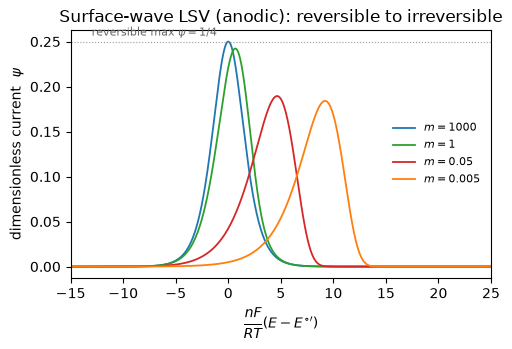

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
for m, c in [(1000.0, "C0"), (1.0, "C2"), (0.05, "C3"), (0.005, "C1")]:
    E, psi = lsv_finite_difference(m, E_lo=-15.0, E_hi=25.0, increments=8000)
    ax.plot(E, psi, color=c, lw=1.3, label=fr"$m={m:g}$")
ax.axhline(0.25, color="0.6", ls=":", lw=0.8)
ax.text(-13, 0.256, r"reversible max $\psi=1/4$", fontsize=8, color="0.4")
ax.set_xlabel(r"$\dfrac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_ylabel(r"dimensionless current  $\psi$")
ax.set_title("Surface-wave LSV (anodic): reversible to irreversible")
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(-15, 25)
fig.tight_layout()
plt.show()


### The reversible limit, by hand

When $m \to \infty$ the surface stays at Nernstian equilibrium at every instant,
$x_\mathrm{O} = 1/(1 + e^{-\mathcal{E}})$. Differentiating,

$$ \psi_{\mathrm{rev}}(\mathcal{E})
   = \frac{\mathrm{d} x_\mathrm{O}}{\mathrm{d}\mathcal{E}}
   = \frac{e^{-\mathcal{E}}}{(1 + e^{-\mathcal{E}})^2}
   = \frac{1}{4}\,\operatorname{sech}^2\!\frac{\mathcal{E}}{2}. $$

This is a **symmetric, bell-shaped** peak centred at $E = E^{\circ\prime}$ with
maximum value exactly $\psi_{\max} = 1/4$. Its width at half height follows from
$\operatorname{sech}^2(\mathcal{E}/2) = 1/2$, i.e.
$\mathcal{E}_{1/2} = \pm 2\operatorname{arccosh}\sqrt 2$, giving a full width

$$ \Delta\mathcal{E}_{\mathrm{FWHM}} = 4\operatorname{arccosh}\sqrt 2
   = 3.5255\ldots, $$

which in millivolts of real potential at 25 °C is
$\Delta E_{\mathrm{FWHM}} = (RT/nF)\,\Delta\mathcal{E}_{\mathrm{FWHM}}
= 90.6/n$ mV — the classic diagnostic of a reversible surface wave (SERM
states the $90.6/n$ mV result). We confirm both numbers below.

In [9]:
# Convergence of the FD recursion to the reversible peak height 1/4.
print("Finite-difference convergence to psi_max = 0.25 (reversible, m large):")
for inc in [200, 1000, 5000, 20000]:
    _, psi = lsv_finite_difference(5000.0, E_lo=-15.0, E_hi=15.0, increments=inc)
    print(f"  increments={inc:6d}   psi_max={psi.max():.6f}   "
          f"err={abs(psi.max()-0.25):.2e}")


Finite-difference convergence to psi_max = 0.25 (reversible, m large):
  increments=   200   psi_max=0.249532   err=4.68e-04
  increments=  1000   psi_max=0.249981   err=1.87e-05
  increments=  5000   psi_max=0.249999   err=7.50e-07
  increments= 20000   psi_max=0.250000   err=4.69e-08


## Validation

**Strategy (AUTHORING_SPEC §5, option 1 — independent closed-form check).** The
reversible surface wave has an exact analytic peak current that is computed
*independently* of our finite-difference code. From the reversible limit derived above,
$\psi_{\max}=1/4$ and the dimensional current is
$i = nFA\Gamma_\mathrm{T}(nF/RT)|\upsilon|\,\psi$, so the peak current is

$$ i_p = \frac{n^2 F^2 A\,\Gamma_\mathrm{T}\,\upsilon}{4 R T}, $$

which is exactly `serm.echem.surface_wave_peak_current` (Bard & Faulkner eq.
14.3.11). We check four independent facts, each with an `assert`:

1. the simulated reversible peak height is $\psi_{\max} = 1/4$;
2. the peak is **symmetric** about $E^{\circ\prime}$;
3. the full width at half maximum is $90.6/n$ mV at 25 °C;
4. the **dimensional** peak current is linear in sweep rate $\upsilon$ (slope
   from a $\log i_p$–$\log\upsilon$ fit equals 1, *not* 1/2), and matches
   `surface_wave_peak_current` to tight tolerance.

In [10]:
# --- High-accuracy reversible voltammogram (m large) -------------------
m_rev = 1.0e4
E, psi = lsv_finite_difference(m_rev, E_lo=-15.0, E_hi=15.0, increments=60000)
# E is strictly increasing; psi is the positive reduction peak.

# 1) peak height and location
psi_max = psi.max()
E_peak = E[np.argmax(psi)]
assert abs(psi_max - 0.25) < 2e-3, psi_max
assert abs(E_peak) < 1e-2, E_peak   # peak sits at E0

# 2) symmetry: psi(E0+d) == psi(E0-d).
d = np.linspace(0, 8, 4000)
psi_plus = np.interp(E_peak + d, E, psi)
psi_minus = np.interp(E_peak - d, E, psi)
sym_err = np.max(np.abs(psi_plus - psi_minus))
assert sym_err < 2e-3, sym_err

# 3) FWHM in dimensionless E, then convert to mV at 25 C for n=1.
half = psi_max / 2.0
left = E < E_peak
right = E > E_peak
E_left = np.interp(half, psi[left], E[left])                 # rising edge
E_right = np.interp(half, psi[right][::-1], E[right][::-1])  # falling edge
fwhm_dimensionless = E_right - E_left
fwhm_analytic = 4.0 * np.arccosh(np.sqrt(2.0))
n = 1
fwhm_mV = (R * T / (n * F)) * fwhm_dimensionless * 1e3
fwhm_mV_analytic = (R * T / (n * F)) * fwhm_analytic * 1e3

print(f"psi_max            = {psi_max:.5f}   (exact 0.25)")
print(f"E_peak             = {E_peak:.4e}   (exact 0)")
print(f"symmetry max error = {sym_err:.2e}")
print(f"FWHM (dimensionless) sim = {fwhm_dimensionless:.4f}  "
      f"analytic = {fwhm_analytic:.4f}")
print(f"FWHM (mV, n=1) sim = {fwhm_mV:.2f} mV  analytic = {fwhm_mV_analytic:.2f} mV")

assert abs(fwhm_dimensionless - fwhm_analytic) < 5e-3, fwhm_dimensionless
assert abs(fwhm_mV - 90.6) < 0.5, fwhm_mV


psi_max            = 0.25000   (exact 0.25)
E_peak             = 5.0000e-04   (exact 0)
symmetry max error = 4.81e-05
FWHM (dimensionless) sim = 3.5255  analytic = 3.5255
FWHM (mV, n=1) sim = 90.58 mV  analytic = 90.58 mV


In [11]:
# --- 4) Dimensional peak current is LINEAR in sweep rate ----------------
n_e = 1
A = 0.02            # cm^2
Gamma_T = 1.0e-9    # mol/cm^2 (a typical full monolayer ~ 1e-9 .. 1e-10)
sweep_rates = np.array([0.01, 0.05, 0.1, 0.5, 1.0])   # V/s

ip_sim = []
for v in sweep_rates:
    # m = RT k_s / (nF v). Pick k_s huge so every sweep stays reversible.
    k_s = 1.0e6
    m = (R * T * k_s) / (n_e * F * v)
    _, psi = lsv_finite_difference(m, E_lo=-15, E_hi=15, increments=30000)
    prefactor = n_e * F * A * Gamma_T * (n_e * F / (R * T)) * v
    ip_sim.append(prefactor * psi.max())
ip_sim = np.array(ip_sim)

ip_ref = np.array([surface_wave_peak_current(n_e, A, Gamma_T, v, temperature=T)
                   for v in sweep_rates])

rel_err = np.abs(ip_sim - ip_ref) / ip_ref
slope = np.polyfit(np.log(sweep_rates), np.log(ip_sim), 1)[0]

print("v (V/s)    i_p sim (A)     i_p ref (A)     rel.err")
for v, a, b, e in zip(sweep_rates, ip_sim, ip_ref, rel_err):
    print(f"  {v:5.2f}   {a:.6e}   {b:.6e}   {e:.2e}")
print(f"\nlog-log slope of i_p vs v = {slope:.4f}  (linear -> 1, diffusion -> 0.5)")

assert np.all(rel_err < 5e-3), rel_err
assert abs(slope - 1.0) < 1e-2, slope
print("\nPASS: reversible surface wave -- psi_max=1/4, symmetric, "
      "FWHM=90.6/n mV, i_p linear in v and matches serm.echem.")


v (V/s)    i_p sim (A)     i_p ref (A)     rel.err
   0.01   1.877689e-07   1.877689e-07   8.33e-08
   0.05   9.388443e-07   9.388444e-07   8.33e-08
   0.10   1.877689e-06   1.877689e-06   8.33e-08
   0.50   9.388443e-06   9.388444e-06   8.33e-08
   1.00   1.877689e-05   1.877689e-05   8.33e-08

log-log slope of i_p vs v = 1.0000  (linear -> 1, diffusion -> 0.5)

PASS: reversible surface wave -- psi_max=1/4, symmetric, FWHM=90.6/n mV, i_p linear in v and matches serm.echem.


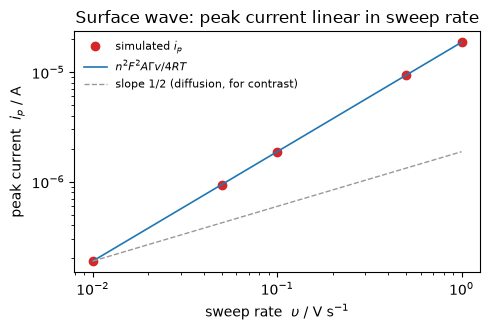

In [12]:
# Figure: i_p vs v on log-log, showing slope 1 (adsorbed) vs the slope-1/2
# scaling a diffusing species would follow.
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.loglog(sweep_rates, ip_sim, "o", color="C3", label="simulated $i_p$")
ax.loglog(sweep_rates, ip_ref, "-", color="C0", lw=1.2,
          label=r"$n^2F^2A\Gamma v/4RT$")
diff_scaling = ip_ref[0] * np.sqrt(sweep_rates / sweep_rates[0])
ax.loglog(sweep_rates, diff_scaling, "--", color="0.6", lw=1.0,
          label=r"slope $1/2$ (diffusion, for contrast)")
ax.set_xlabel(r"sweep rate  $\upsilon$ / V s$^{-1}$")
ax.set_ylabel(r"peak current  $i_p$ / A")
ax.set_title("Surface wave: peak current linear in sweep rate")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Summary

For a **strongly adsorbed / surface-confined** redox couple there is no
diffusion: the entire response follows from a single ordinary differential
equation for the mole fraction $x_\mathrm{O}(t)$ under Butler–Volmer kinetics.

* A **potential step** gives a pure exponential relaxation with time constant
  $1/(k_f+k_b)$ — verified against `solve_ivp` to machine precision.
* A **linear sweep** is governed by one dimensionless group
  $m = RT k_s / (nF|\upsilon|)$, taking the voltammogram from the reversible
  bell-shaped peak ($m\to\infty$) through quasi-reversibility to the asymmetric
  irreversible peak ($m\to 0$). Both an ODE integration and the SERM
  finite-difference stepping recursion were implemented and shown to agree and
  to converge to the analytic reversible peak.
* The reversible surface wave is the key diagnostic: a **symmetric** peak at
  $E^{\circ\prime}$ with $\psi_{\max}=1/4$, full width at half maximum
  $\Delta E = 90.6/n$ mV at 25 °C, and peak current
  $i_p = n^2F^2A\Gamma_\mathrm{T}\upsilon/4RT$ that is **linear** in sweep rate
  (log–log slope $1.0000$ from the fit), in contrast to the $\sqrt\upsilon$
  Randles–Ševčík scaling of a diffusing species. The validation asserts all of
  these against `serm.echem.surface_wave_peak_current` to better than $0.5\%$.

SERM closes the chapter with **Marcus theory** kinetics (replacing Butler–Volmer
$k_{f/b}$ with the Marcus–Hush rate integral), which predicts a sweep-rate- and
$\lambda$-dependent peak shape rather than the constant irreversible shape of
Butler–Volmer; the same stepping machinery here drives that simulation once the
rates are swapped.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 10 — Thin Layers and Thin Films](10_thin_layers_and_films.ipynb) | [Chapter 12 — Monte Carlo Simulations →](12_monte_carlo.ipynb) |

[Contents (README)](../README.md)